In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
%matplotlib inline

In [ ]:
X,y = make_blobs(n_samples=1000,n_features=2,centers=3,random_state=23)

In [ ]:
X.shape

(1000, 2)

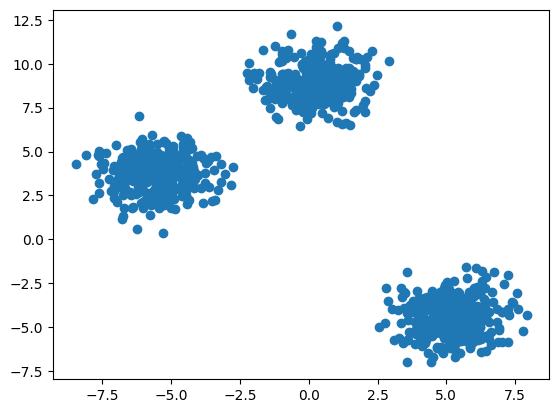

In [ ]:
plt.scatter(X[:,0],X[:,1])

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
## finding K
## manual Process
## Elbow method

wcss = []
for k in range (1,11):
  kmeans = KMeans(n_clusters=k,init='k-means++')
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

In [ ]:
wcss


[51206.31443977728,
 12017.096385908864,
 1978.419762413035,
 1763.2710782511576,
 1518.5203738917214,
 1314.2065297703775,
 1171.9138492098384,
 1024.6096499281243,
 876.7222806740232,
 818.2485483217391]

Text(0, 0.5, 'WCSS')

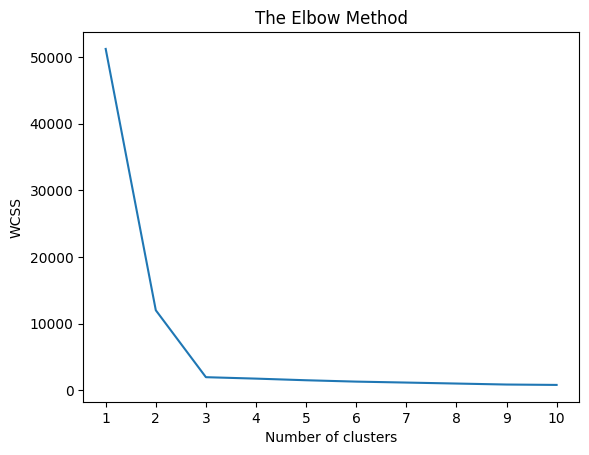

In [ ]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

In [ ]:
kmeans_ = KMeans(n_clusters=3,init='k-means++')

In [ ]:
ylabels = kmeans_.fit_predict(X_train)

In [ ]:
ytest_label = kmeans_.predict(X_test)

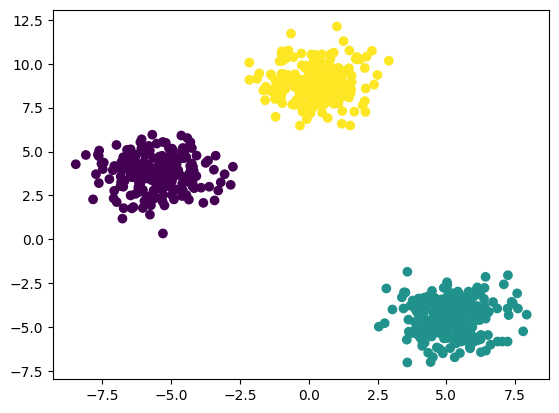

In [ ]:
plt.scatter(X_train[:,0],X_train[:,1],c=ylabels)

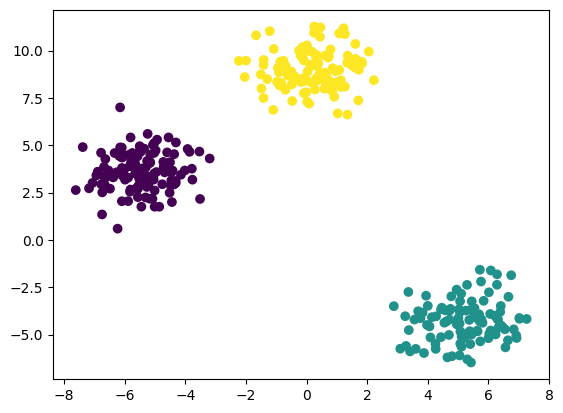

In [ ]:
plt.scatter(X_test[:,0],X_test[:,1],c=ytest_label)


In [ ]:
## automatic K value
## knee locator


In [ ]:
!pip install kneed

In [ ]:
from kneed import KneeLocator

In [ ]:
k1 = KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
# curve = concave when wcss increasing

In [ ]:
print(k1.elbow)

3


In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in range(2, 11): # Silhouette score requires at least 2 clusters
  kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
  kmeans.fit(X_train)
  score = silhouette_score(X_train, kmeans.labels_)
  silhouette_scores.append(score)

silhouette_scores

[np.float64(0.7281443868598331),
 np.float64(0.8071181203797672),
 np.float64(0.6357733426488265),
 np.float64(0.4723297879921876),
 np.float64(0.33367872107343594),
 np.float64(0.32758752735600283),
 np.float64(0.33049705268923796),
 np.float64(0.3233874690312625),
 np.float64(0.32630032779404855)]

Text(0, 0.5, 'Silhouette Score')

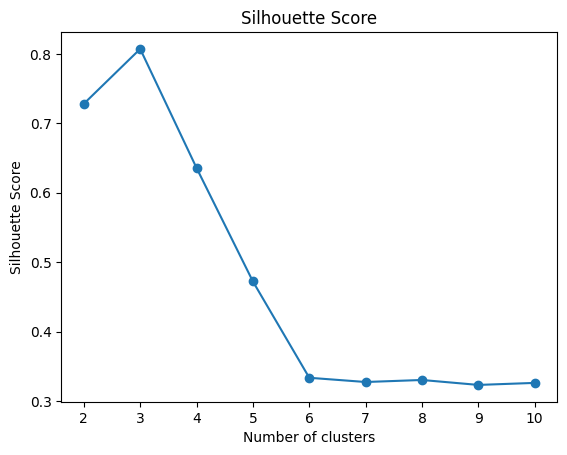

In [ ]:
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xticks(range(2, 11))
plt.title('Silhouette Score')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')